In [1]:
import os
import math
import datetime
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from tensorflow.keras import layers, models, Input
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import TopKCategoricalAccuracy
from tensorflow.keras.optimizers.schedules import ExponentialDecay
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.callbacks import ReduceLROnPlateau


c:\Users\pondt\anaconda3\envs\efficientnet\lib\site-packages\h5py\__init__.py:36: UserWarning: h5py is running against HDF5 1.14.6 when it was built against 1.14.5, this may cause problems
  _warn(("h5py is running against HDF5 {0} when it was built against {1}, "


In [2]:
# === DATA SETUP === #
AUTOTUNE = tf.data.AUTOTUNE
BATCH_SIZE = 32
IMG_SIZE = (224, 224)
DATASET_DIR = "D:/Senior_WorkTable/GrowQuest_Data_Final"

In [3]:
# Load Datasets
def load_datasets():
    train_ds = tf.keras.utils.image_dataset_from_directory(
        os.path.join(DATASET_DIR, "train"), label_mode="categorical",
        image_size=IMG_SIZE, batch_size=BATCH_SIZE, shuffle=True, seed=42)

    val_ds = tf.keras.utils.image_dataset_from_directory(
        os.path.join(DATASET_DIR, "val"), label_mode="categorical",
        image_size=IMG_SIZE, batch_size=BATCH_SIZE, shuffle=False)

    test_ds = tf.keras.utils.image_dataset_from_directory(
        os.path.join(DATASET_DIR, "test"), label_mode="categorical",
        image_size=IMG_SIZE, batch_size=1, shuffle=False)

    return train_ds, val_ds, test_ds

train_ds, val_ds, test_ds = load_datasets()


Found 4199 files belonging to 3 classes.
Found 900 files belonging to 3 classes.
Found 900 files belonging to 3 classes.


In [ ]:
# Augmentation + Normalization
class_names = train_ds.class_names



def preprocess(image, label):
    image = tf.cast(image, tf.float32)
    image = preprocess_input(image)  # ResNet expects [-1, 1] with mean subtraction
    return image, label


data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.2),
    layers.RandomBrightness(0.3),
    layers.RandomTranslation(0.1, 0.1),
    layers.GaussianNoise(0.05),
    layers.RandomCrop(224, 224)
])

def augment(image, label):
    return data_augmentation(image, training=True), label

train_ds = train_ds.map(preprocess).map(augment).cache().shuffle(1000).repeat().prefetch(AUTOTUNE)
val_ds = val_ds.map(preprocess).cache().prefetch(AUTOTUNE)
test_ds = test_ds.map(preprocess).prefetch(AUTOTUNE)

In [5]:
# === MODEL SETUP === #
def build_resnet50_base(input_shape=(224, 224, 3), trainable=False):
    base_model = ResNet50(
        input_shape=input_shape, include_top=False, weights='imagenet')
    base_model.trainable = trainable
    return base_model

def build_custom_classifier(base_model, input_shape=(224, 224, 3), num_classes=3, dropout_rate=0.5):
    inputs = Input(shape=input_shape, name="input_image")
    x = base_model(inputs, training=False)
    x = layers.Conv2D(64, (1, 1), activation='relu')(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(128, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)
    x = layers.Dropout(dropout_rate)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    return models.Model(inputs, outputs)


base_model = build_resnet50_base(trainable=False)
model = build_custom_classifier(base_model)

In [6]:
# Optimizer + Compile
lr_schedule = ExponentialDecay(1e-4, decay_steps=10000, decay_rate=0.9, staircase=True)
metrics = ['accuracy', TopKCategoricalAccuracy(k=2, name='top_2_accuracy')]
optimizer = Adam(learning_rate=1e-4)
model.compile(
    optimizer=optimizer,
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy', tf.keras.metrics.TopKCategoricalAccuracy(k=2)]
)


In [7]:
# Callbacks
log_dir = os.path.join("logs", datetime.datetime.now().strftime("%Y%m%d-%H%M%S"))
callbacks = [
    EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True, verbose=1),
    ModelCheckpoint(filepath='checkpoints/best_model_resnet50.keras',
                    save_best_only=True, monitor='val_loss', verbose=1)
]



callbacks.append(
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=1
    )
)


In [8]:
# === PHASE 1: Transfer Learning === #
steps_per_epoch = math.ceil(4199 / BATCH_SIZE)
validation_steps = math.ceil(900 / BATCH_SIZE)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    steps_per_epoch=steps_per_epoch,
    validation_steps=validation_steps,
    callbacks=callbacks
)
pd.DataFrame(history.history).to_csv("training_history_resnet50.csv", index=False)


Epoch 1/50
131/132 [============================>.] - ETA: 0s - loss: 1.2882 - accuracy: 0.4212 - top_k_categorical_accuracy: 0.7461
Epoch 1: val_loss improved from inf to 1.00089, saving model to checkpoints\best_model_resnet50.keras
132/132 [==============================] - 95s 74ms/step - loss: 1.2852 - accuracy: 0.4225 - top_k_categorical_accuracy: 0.7473 - val_loss: 1.0009 - val_accuracy: 0.5367 - val_top_k_categorical_accuracy: 0.8144 - lr: 1.0000e-04
Epoch 2/50
132/132 [==============================] - ETA: 0s - loss: 1.0601 - accuracy: 0.5330 - top_k_categorical_accuracy: 0.8257
Epoch 2: val_loss improved from 1.00089 to 0.94917, saving model to checkpoints\best_model_resnet50.keras
132/132 [==============================] - 5s 40ms/step - loss: 1.0601 - accuracy: 0.5330 - top_k_categorical_accuracy: 0.8257 - val_loss: 0.9492 - val_accuracy: 0.5889 - val_top_k_categorical_accuracy: 0.8567 - lr: 1.0000e-04
Epoch 3/50
132/132 [==============================] - ETA: 0s - loss: 0

In [9]:
# === PHASE 2: Fine-Tuning === #
fine_tune_at = len(base_model.layers) - 80
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False
for layer in base_model.layers[fine_tune_at:]:
    layer.trainable = True

loss_fn = tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1)
model.compile(optimizer=Adam(3e-6), loss=loss_fn, metrics=metrics)

fine_tune_history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=70,
    steps_per_epoch=steps_per_epoch,
    validation_steps=validation_steps,
    callbacks=callbacks
)
pd.DataFrame(fine_tune_history.history).to_csv("fine_tuning_history_resnet50.csv", index=False)

Epoch 1/70
132/132 [==============================] - ETA: 0s - loss: 0.7282 - accuracy: 0.7476 - top_2_accuracy: 0.9376
Epoch 1: val_loss did not improve from 0.76769
132/132 [==============================] - 9s 44ms/step - loss: 0.7282 - accuracy: 0.7476 - top_2_accuracy: 0.9376 - val_loss: 0.7786 - val_accuracy: 0.7133 - val_top_2_accuracy: 0.9311 - lr: 3.0000e-06
Epoch 2/70
132/132 [==============================] - ETA: 0s - loss: 0.7291 - accuracy: 0.7545 - top_2_accuracy: 0.9402
Epoch 2: val_loss did not improve from 0.76769
132/132 [==============================] - 5s 36ms/step - loss: 0.7291 - accuracy: 0.7545 - top_2_accuracy: 0.9402 - val_loss: 0.7817 - val_accuracy: 0.7144 - val_top_2_accuracy: 0.9333 - lr: 3.0000e-06
Epoch 3/70
132/132 [==============================] - ETA: 0s - loss: 0.7312 - accuracy: 0.7430 - top_2_accuracy: 0.9338
Epoch 3: val_loss did not improve from 0.76769
132/132 [==============================] - 5s 36ms/step - loss: 0.7312 - accuracy: 0.7430 

1/1 [==============================] - 0s 23ms/step
              precision    recall  f1-score   support

 Anthracnose       0.72      0.70      0.71       300
Healthy_Leaf       0.83      0.78      0.81       300
 Pest_Damage       0.63      0.69      0.66       300

    accuracy                           0.72       900
   macro avg       0.73      0.72      0.73       900
weighted avg       0.73      0.72      0.73       900



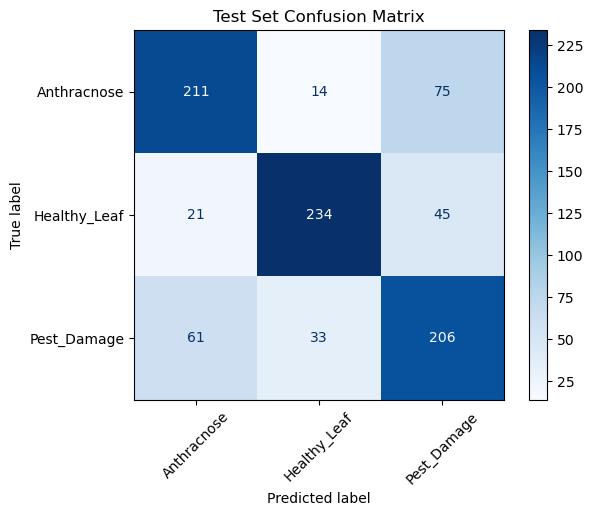

900/900 [==============================] - 13s 14ms/step - loss: 0.7703 - accuracy: 0.7233 - top_2_accuracy: 0.9378
✅ loss: 0.7703
✅ accuracy: 0.7233
✅ top_2_accuracy: 0.9378


In [10]:
# === EVALUATION === #
y_true, y_pred = [], []
for images, labels in test_ds:
    preds = model.predict(images)
    y_pred.append(np.argmax(preds))
    y_true.append(np.argmax(labels.numpy()))

print(classification_report(y_true, y_pred, target_names=class_names))
cm = confusion_matrix(y_true, y_pred)
ConfusionMatrixDisplay(cm, display_labels=class_names).plot(cmap='Blues', xticks_rotation=45)
plt.title("Test Set Confusion Matrix")
plt.show()

results = model.evaluate(test_ds, verbose=1)
for name, value in zip(model.metrics_names, results):
    print(f"✅ {name}: {value:.4f}")


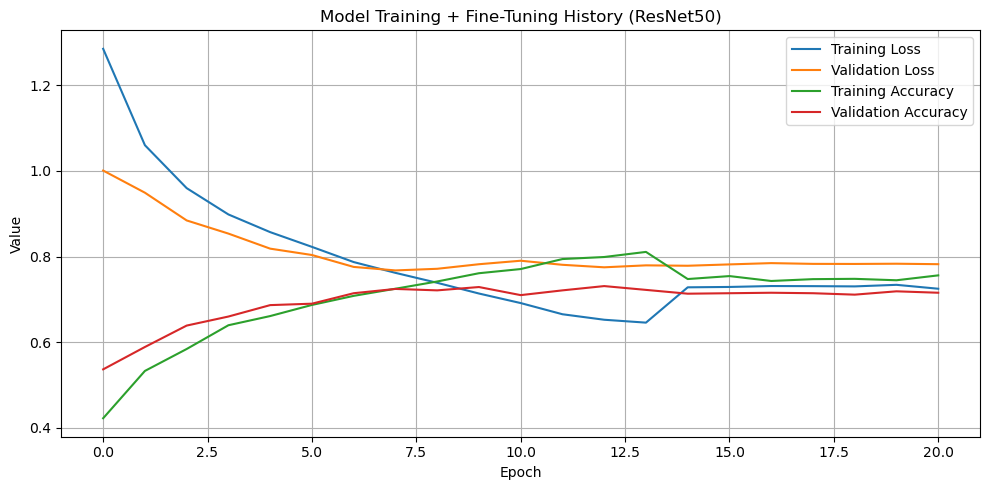

In [11]:
# === PLOTTING === #
train_history = pd.read_csv("training_history_resnet50.csv")
fine_history = pd.read_csv("fine_tuning_history_resnet50.csv")
full_history = pd.concat([train_history, fine_history], ignore_index=True)

plt.figure(figsize=(10, 5))
plt.plot(full_history["loss"], label="Training Loss")
plt.plot(full_history["val_loss"], label="Validation Loss")
plt.plot(full_history["accuracy"], label="Training Accuracy")
plt.plot(full_history["val_accuracy"], label="Validation Accuracy")
plt.title("Model Training + Fine-Tuning History (ResNet50)")
plt.xlabel("Epoch")
plt.ylabel("Value")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

model.save("final_plant_model_resnet50_V2.h5")

In [12]:
model.save("final_plant_model_resnet50_V2.h5")